> **This is a research notebook — one of seven, one per section of the paper.**
>
> For the presentation version, read the two self-contained notebooks in
> [`final/`](../final/) instead: [`1_information_bottleneck.ipynb`](../final/1_information_bottleneck.ipynb) (the whole argument, end to end) and [`2_transformer_extension.ipynb`](../final/2_transformer_extension.ipynb).
>
> This one is the deep dive on deep linear networks, where the mutual information is exact.

# 3 — Deep linear networks: exact mutual information, and no compression

**Reproduces:** paper section 3 — figures 3, 4A–B, F1, H1, and equation (C.5).

---

## Why linear networks

Notebook 1 showed that a tanh unit's apparent compression comes from saturation plus
binning. But that leaves an obvious objection open: maybe compression in real networks
comes from somewhere else entirely — neurons becoming correlated, or the network
projecting out irrelevant input directions. Neither is visible in a one-neuron model.

**Deep linear networks** are the right tool for that question. A depth-$D$ linear network
computes $\hat{Y} = W_{D+1}W_D\cdots W_1 X$. It can only represent linear maps, but:

* its optimisation problem is still non-convex (Baldi & Hornik 1989),
* its learning dynamics are still genuinely nonlinear in time (Saxe, McClelland & Ganguli 2014),
* it exhibits real overtraining (Fukumizu 1998; Advani & Saxe 2017), **and**
* every hidden layer is *jointly Gaussian* with the input and the output.

That last point is decisive: the mutual information can be written down in **closed form**.
No binning, no kernel density estimate, no $k$-NN — no estimator at all. If the information
plane still shows no compression here, it cannot be blamed on estimator error.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / "ibdl").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from ibdl import plotting
plotting.use_paper_style()
FIGDIR = ROOT / "figures"
FIGDIR.mkdir(exist_ok=True)

print("project root:", ROOT)

project root: /home/hooman/Desktop/InfoTheory/Project


## 3.1 Setup

**Teacher** (figure 3A) — generates the data:

$$X \sim \mathcal{N}\!\big(0, \tfrac{1}{N_i}I_{N_i}\big), \qquad
  Y = W_o X + \epsilon_o, \qquad
  \epsilon_o \sim \mathcal{N}(0,\sigma_o^2), \qquad
  W_{o,ij} \sim \mathcal{N}(0,\sigma_w^2).$$

The ratio $\mathrm{SNR} = \sigma_w^2/\sigma_o^2$ sets how much of $Y$ is learnable at all.
$\epsilon_o$ is **approximation error** — structure no network of this class can capture.

**Student** (figure 3B) — a deep linear network trained on $P$ samples by gradient descent.

**Analysis noise.** $T = \bar{W}X$ is deterministic, so $I(T;X)=\infty$ as always. For the
analysis *only* we set $T = \bar{W}X + \epsilon_{MI}$, $\epsilon_{MI}\sim\mathcal{N}(0,\sigma_{MI}^2 I)$
with $\sigma_{MI}^2=1$. This noise is **not** present during training or testing. Then

$$I(T;X) = \tfrac12\log\big|\bar{W}\Sigma_X\bar{W}^\top + \sigma_{MI}^2 I\big|
        - \tfrac12\log\big|\sigma_{MI}^2 I\big| \tag{6}$$

and $I(T;Y)$ follows from $H(T)+H(Y)-H(T,Y)$, equations (G.1)–(G.4). The exact
generalisation error is available too:

$$E_g = \mathrm{tr}\big[(W_o - W_{tot})\Sigma_X (W_o-W_{tot})^\top\big] + \sigma_o^2 N_o. \tag{5}$$

> **Note on the paper's equations.** The text states $X\sim\mathcal{N}(0,\tfrac1{N_i}I)$,
> but equations (5), (6) and (G.1)–(G.3) are written with $\Sigma_X$ suppressed (as if
> $\Sigma_X=I$), and (6) also drops the $\tfrac12$ that appears correctly in (G.2). We keep
> $\Sigma_X$ explicit and keep the $\tfrac12$. This changes the axis scale by a constant,
> not any conclusion — and it puts $I(X;T)$ in the same $\approx 0.5$–$2.5$ bit range as
> the paper's own figure 3D.

In [2]:
from ibdl.cache import cached
from ibdl.experiments import LinearConfig, run_linear

# Figure 3: N_i = 100, one hidden layer of 100, P = 100, SNR = 1, batch gradient
# descent. The paper's figure 3 colour bar tops out at epoch 499, so 500 epochs.
cfg_fig3 = LinearConfig(hidden=(100,), n_train=100, batch_size=None, lr=0.02,
                        n_epochs=500, n_checkpoints=120, seed=0)
res3 = cached(cfg_fig3.tag, lambda: run_linear(cfg_fig3))

L = res3.log
print(f"layers            : {L.layer_names}")
print(f"checkpoints       : {len(L.epochs)} over {L.epochs[-1]} epochs")
print(f"train MSE         : {L.train_loss[0]:.3f} -> {L.train_loss[-1]:.3f}")
print(f"test  MSE         : {L.test_loss[0]:.3f} -> {L.test_loss[-1]:.3f}"
      f"   (min {L.test_loss.min():.3f} @ epoch {L.epochs[L.test_loss.argmin()]})")
print(f"exact E_g         : {res3.E_g[0]:.3f} -> {res3.E_g[-1]:.3f}"
      f"   (irreducible floor sigma_o^2 = {res3.sigma_o**2:.3f})")

[cache] loaded 'linear_100-100-1_P100_snr1_bgd_lr0.02_e500_s0' (10.4 MB)
layers            : ['L1 (100)', 'L2 (1)']
checkpoints       : 134 over 500 epochs
train MSE         : 1.838 -> 0.462
test  MSE         : 1.926 -> 1.599   (min 1.579 @ epoch 371)
exact E_g         : 1.945 -> 1.609   (irreducible floor sigma_o^2 = 1.000)


## 3.2 Figure 3C/3D — generalises well, and does not compress

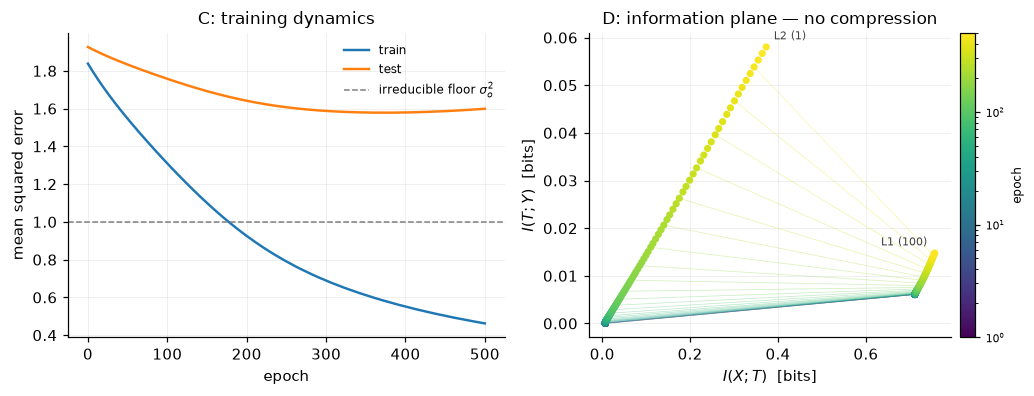

layer          I(X;T) start -> end   largest single drop   compression (peak - final)
L1 (100)        0.712 ->  0.756   -3.01e-05 bits        +0.00000 bits
L2 (1)          0.007 ->  0.373   -9.97e-05 bits        +0.00000 bits

total rise per layer          : [0.045  0.3665] bits
largest single-step decrease   : -1.0e-04 bits

The curves are not literally monotone -- individual gradient steps can nudge a
singular value of the layer map down by ~1e-5 bits -- but that is four orders of
magnitude below the overall rise, and neither layer ever ends below its peak.
There is no compression phase in any meaningful sense.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.7))

ax = axes[0]
ax.plot(L.epochs, L.train_loss, label="train", color="#1f77b4")
ax.plot(L.epochs, L.test_loss, label="test", color="#ff7f0e")
ax.axhline(res3.sigma_o**2, ls="--", lw=1, color="0.5",
           label=r"irreducible floor $\sigma_o^2$")
ax.set_xlabel("epoch"); ax.set_ylabel("mean squared error")
ax.set_title("C: training dynamics")
ax.legend()

plotting.information_plane(
    L.epochs, res3.I_XT, res3.I_TY, ax=axes[1],
    title="D: information plane — no compression",
    layer_names=L.layer_names, annotate_layers=True,
)
fig.tight_layout()
plotting.save(fig, "fig03CD_linear_bgd", FIGDIR)
plt.show()

print("layer          I(X;T) start -> end   largest single drop   compression (peak - final)")
for j, name in enumerate(L.layer_names):
    x = res3.I_XT[:, j]
    worst_step = float(np.diff(x).min())          # negative => a decrease somewhere
    drawdown = float(x.max() - x[-1])             # how far below its peak it ends
    print(f"{name:14s} {x[0]:6.3f} -> {x[-1]:6.3f}   {worst_step:+.2e} bits"
          f"        {drawdown:+.5f} bits")
span = res3.I_XT.max(0) - res3.I_XT.min(0)
print(f"\ntotal rise per layer          : {np.round(span, 4)} bits")
print(f"largest single-step decrease   : {np.diff(res3.I_XT, axis=0).min():.1e} bits")
print("\nThe curves are not literally monotone -- individual gradient steps can nudge a")
print("singular value of the layer map down by ~1e-5 bits -- but that is four orders of")
print("magnitude below the overall rise, and neither layer ever ends below its peak.")
print("There is no compression phase in any meaningful sense.")

Both layers move **monotonically to the right**: $I(X;T)$ only ever increases. There is no
compression phase at all, yet the network generalises — test error tracks train error down
to near the irreducible floor $\sigma_o^2$.

So already: **good generalisation without any compression.** That is one half of the
dissociation.

## 3.3 Figure 4A/4B — the other half: severe overfitting, still no compression

Advani & Saxe (2017) show that in linear networks overtraining is worst when the number of
training samples matches the number of inputs, $P = N_i$ — the classic interpolation peak.
Figure 4 sits exactly there ($N_i = P = 100$) and switches to **SGD with 5 samples per
batch**, which makes 20 updates per epoch instead of one and drives the network deep into
the interpolating regime.

[cache] loaded 'linear_100-100-1_P100_snr1_sgd5_lr0.02_e2000_s1' (9.3 MB)


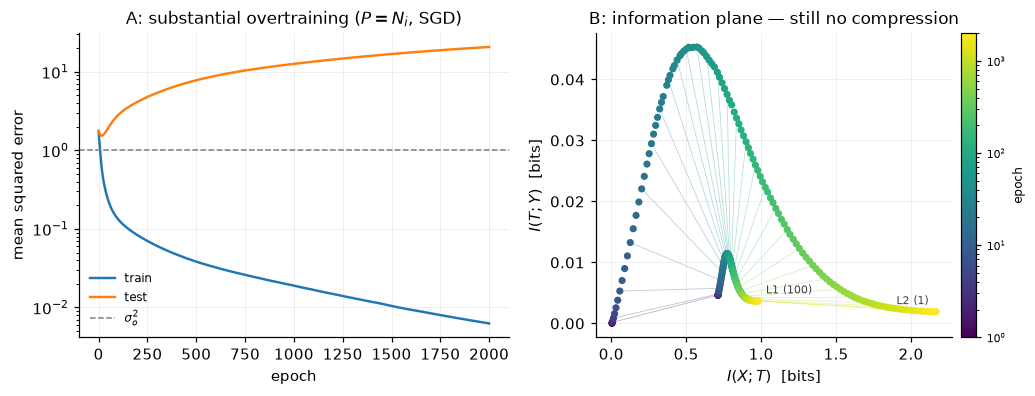

test MSE: min 1.538 @ epoch 15  ->  final 20.73   (13.5x worse)
train MSE final: 0.00626  (memorised the training set)
L1 (100)       I(X;T)  0.712 ->  0.981   compression +0.0000 bits
L2 (1)         I(X;T)  0.005 ->  2.167   compression +0.0000 bits


In [4]:
cfg_fig4 = LinearConfig(hidden=(100,), n_train=100, batch_size=5, lr=0.02,
                        n_epochs=2_000, n_checkpoints=100, seed=1)
res4 = cached(cfg_fig4.tag, lambda: run_linear(cfg_fig4))
L4 = res4.log

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.7))
ax = axes[0]
ax.plot(L4.epochs, L4.train_loss, label="train", color="#1f77b4")
ax.plot(L4.epochs, L4.test_loss, label="test", color="#ff7f0e")
ax.axhline(res4.sigma_o**2, ls="--", lw=1, color="0.5", label=r"$\sigma_o^2$")
ax.set_yscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel("mean squared error")
ax.set_title("A: substantial overtraining ($P = N_i$, SGD)")
ax.legend()

plotting.information_plane(
    L4.epochs, res4.I_XT, res4.I_TY, ax=axes[1],
    title="B: information plane — still no compression",
    layer_names=L4.layer_names, annotate_layers=True,
)
fig.tight_layout()
plotting.save(fig, "fig04AB_linear_overfit", FIGDIR)
plt.show()

print(f"test MSE: min {L4.test_loss.min():.3f} @ epoch {L4.epochs[L4.test_loss.argmin()]}"
      f"  ->  final {L4.test_loss[-1]:.2f}   ({L4.test_loss[-1] / L4.test_loss.min():.1f}x worse)")
print(f"train MSE final: {L4.train_loss[-1]:.5f}  (memorised the training set)")
for j, name in enumerate(L4.layer_names):
    x = res4.I_XT[:, j]
    print(f"{name:14s} I(X;T) {x[0]:6.3f} -> {x[-1]:6.3f}   compression {x.max() - x[-1]:+.4f} bits")

## 3.4 The dissociation, stated plainly

Two networks. Same architecture, same data-generating process, same exact information
measure. Their information-plane behaviour is **identical** (monotone increase, no
compression); their generalisation behaviour is **completely different**.

In [5]:
import textwrap

rows = [
    ("figure 3 (BGD, 500 ep)", res3, cfg_fig3),
    ("figure 4 (SGD b=5, 2000 ep)", res4, cfg_fig4),
]
print(f"{'setting':30s} {'compression?':>13s} {'final E_g':>11s} {'E_g / floor':>12s}  generalises?")
print("-" * 88)
for name, r, c in rows:
    comp = max(r.I_XT.max(0) - r.I_XT[-1])
    ratio = r.E_g[-1] / (r.sigma_o**2)
    print(f"{name:30s} {'no' if comp < 0.01 else f'{comp:.2f} bits':>13s} "
          f"{r.E_g[-1]:11.2f} {ratio:12.1f}  {'yes' if ratio < 3 else 'NO'}")

print()
print(textwrap.fill(
    "Neither network compresses, yet one generalises and the other does not. "
    "Compression therefore cannot be what explains generalisation here -- there is "
    "no variation in compression to explain the variation in generalisation.", 88))

setting                         compression?   final E_g  E_g / floor  generalises?
----------------------------------------------------------------------------------------
figure 3 (BGD, 500 ep)                    no        1.61          1.6  yes
figure 4 (SGD b=5, 2000 ep)               no       20.30         20.3  NO

Neither network compresses, yet one generalises and the other does not. Compression
therefore cannot be what explains generalisation here -- there is no variation in
compression to explain the variation in generalisation.


## 3.5 Figure F1 — a deeper linear network

Five hidden layers of 50 units, same regime. Depth does not introduce a compression
mechanism either.

[cache] loaded 'linear_100-50-50-50-50-50-1_P100_snr1_bgd_lr0.02_e500_s0' (25.8 MB)


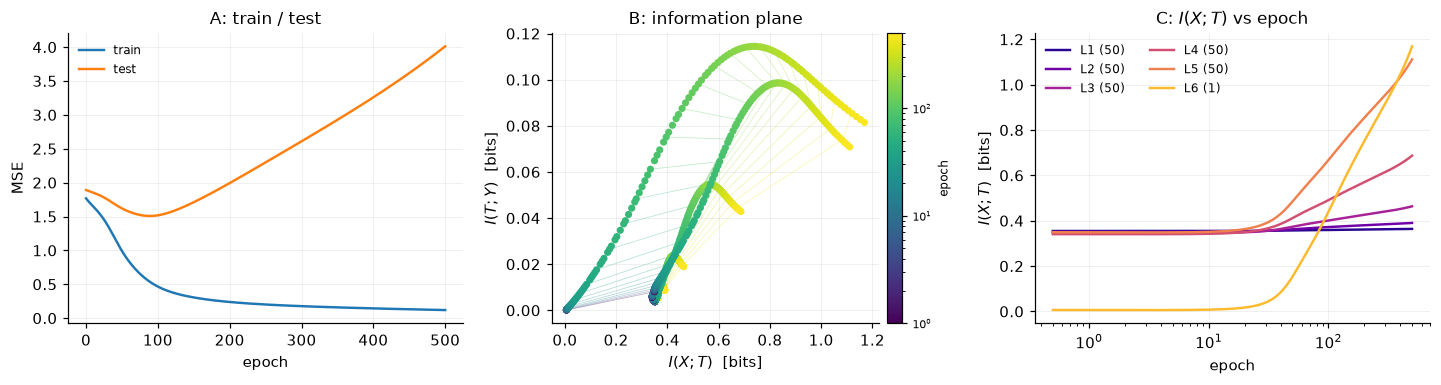

compression per layer (peak - final), 5 hidden layers:
  L1 (50)      +0.00000 bits
  L2 (50)      +0.00000 bits
  L3 (50)      +0.00000 bits
  L4 (50)      +0.00000 bits
  L5 (50)      +0.00000 bits
  L6 (1)       +0.00000 bits


In [6]:
cfg_deep = LinearConfig(hidden=(50, 50, 50, 50, 50), n_train=100, batch_size=None,
                        lr=0.02, n_epochs=500, n_checkpoints=120, seed=0)
res_deep = cached(cfg_deep.tag, lambda: run_linear(cfg_deep))
Ld = res_deep.log

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.6))
axes[0].plot(Ld.epochs, Ld.train_loss, label="train", color="#1f77b4")
axes[0].plot(Ld.epochs, Ld.test_loss, label="test", color="#ff7f0e")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE"); axes[0].set_title("A: train / test")
axes[0].legend()

plotting.information_plane(Ld.epochs, res_deep.I_XT, res_deep.I_TY, ax=axes[1],
                           title="B: information plane", layer_names=Ld.layer_names)
plotting.layer_curves(Ld.epochs, res_deep.I_XT, ax=axes[2], layer_names=Ld.layer_names,
                      ylabel=r"$I(X;T)$  [bits]", title="C: $I(X;T)$ vs epoch", logx=True)
fig.tight_layout()
plotting.save(fig, "figF1_deep_linear", FIGDIR)
plt.show()

print("compression per layer (peak - final), 5 hidden layers:")
for j, name in enumerate(Ld.layer_names):
    x = res_deep.I_XT[:, j]
    print(f"  {name:12s} {x.max() - x[-1]:+.5f} bits")

## 3.6 Figure H1 — stochastic versus batch gradient descent

Section 4's claim in miniature: if SGD's randomness drove information dynamics, replacing
it with deterministic full-batch descent should change the picture. It does not.

[cache] loaded 'linear_100-100-1_P100_snr1_bgd_lr0.02_e2000_s1' (9.3 MB)


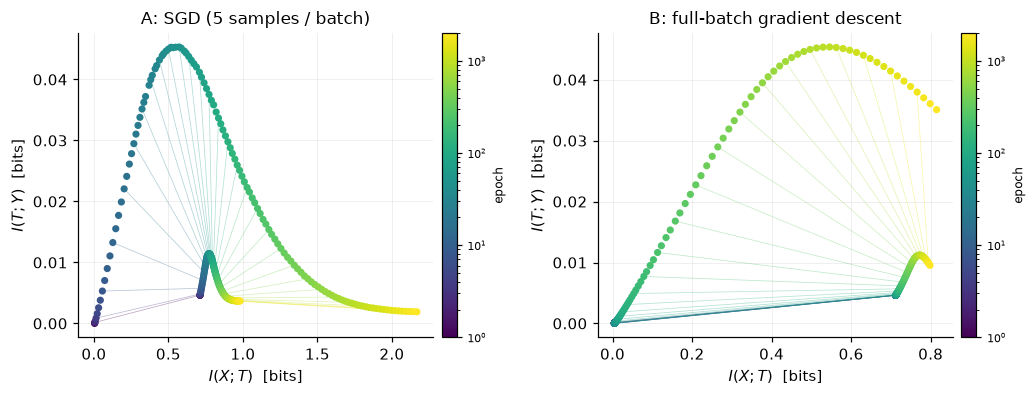

SGD: I(X;T) final [0.981 2.167]   max compression +0.0000 bits
BGD: I(X;T) final [0.798 0.815]   max compression +0.0000 bits


In [7]:
cfg_bgd = LinearConfig(hidden=(100,), n_train=100, batch_size=None, lr=0.02,
                       n_epochs=2_000, n_checkpoints=100, seed=1)
res_bgd = cached(cfg_bgd.tag, lambda: run_linear(cfg_bgd))

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.7))
plotting.information_plane(res4.log.epochs, res4.I_XT, res4.I_TY, ax=axes[0],
                           title="A: SGD (5 samples / batch)", layer_names=res4.log.layer_names)
plotting.information_plane(res_bgd.log.epochs, res_bgd.I_XT, res_bgd.I_TY, ax=axes[1],
                           title="B: full-batch gradient descent", layer_names=res_bgd.log.layer_names)
fig.tight_layout()
plotting.save(fig, "figH1_sgd_vs_bgd_linear", FIGDIR)
plt.show()

for label, r in [("SGD", res4), ("BGD", res_bgd)]:
    print(f"{label}: I(X;T) final {np.round(r.I_XT[-1], 3)}   "
          f"max compression {max(r.I_XT.max(0) - r.I_XT[-1]):+.4f} bits")

## 3.7 Equation (C.5) — the measure is not a property of the function computed

This is the sharpest point in the appendix. Consider a scalar two-layer linear network
$\hat{y} = w_2 w_1 x$, and rescale $\tilde{w}_1 = w_1/c$, $\tilde{w}_2 = c\,w_2$. Every
member of this family computes **exactly the same input–output map**, so they all
generalise **identically**. But the hidden activity is $h = \tilde{w}_1 x$, and once the
analysis noise is added,

$$I(T;X) = \tfrac12\log\big(w_1^2/c^2 + \sigma_{MI}^2\big) - \tfrac12\log \sigma_{MI}^2 \tag{C.5}$$

which depends on $c$. Mutual information is invariant to invertible reparametrisation —
but $T = h + \epsilon$ is *not*, because the noise is added at a fixed scale. So two
networks that are functionally indistinguishable can be given arbitrarily different
"information content".

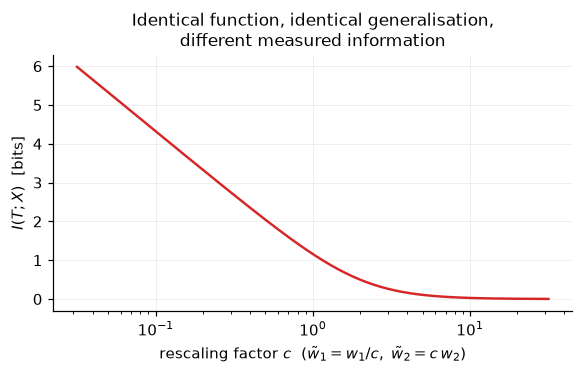

       c   w1_tilde   w2_tilde   output map   I(T;X) [bits]
    0.10     20.000      0.300        6.000           4.324
    0.50      4.000      1.500        6.000           2.044
    1.00      2.000      3.000        6.000           1.161
    2.00      1.000      6.000        6.000           0.500
   10.00      0.200     30.000        6.000           0.028

The output map is identical in every row. The information is not.


In [8]:
from ibdl.estimators.gaussian import gaussian_mi_input

w1, sigma_mi2 = 2.0, 1.0
cs = np.logspace(-1.5, 1.5, 200)
mi = np.array([gaussian_mi_input(np.array([[w1 / c]]), sigma_mi2=sigma_mi2, sigma_x2=1.0)
               for c in cs])

fig, ax = plt.subplots(figsize=(5.4, 3.5))
ax.plot(cs, mi, color="#d62728")
ax.set_xscale("log")
ax.set_xlabel(r"rescaling factor $c$  ($\tilde{w}_1 = w_1/c,\;\tilde{w}_2 = c\,w_2$)")
ax.set_ylabel(r"$I(T;X)$  [bits]")
ax.set_title("Identical function, identical generalisation,\ndifferent measured information")
fig.tight_layout()
plotting.save(fig, "figC5_rescaling", FIGDIR)
plt.show()

print(f"{'c':>8s} {'w1_tilde':>10s} {'w2_tilde':>10s} {'output map':>12s} {'I(T;X) [bits]':>15s}")
for c in [0.1, 0.5, 1.0, 2.0, 10.0]:
    m = gaussian_mi_input(np.array([[w1 / c]]), sigma_mi2=sigma_mi2, sigma_x2=1.0)
    print(f"{c:8.2f} {w1 / c:10.3f} {c * 3.0:10.3f} {3.0 * w1:12.3f} {m:15.3f}")
print("\nThe output map is identical in every row. The information is not.")

## 3.8 What happens past the paper's window

The paper stops figure 3 at epoch 499. Running the identical setup 40× longer is worth
seeing: because $P = N_i$ exactly, batch gradient descent eventually drives the network to
the interpolating solution and the test error blows up — while $I(X;T)$ keeps rising.

[cache] loaded 'linear_100-100-1_P100_snr1_bgd_lr0.02_e20000_s0' (10.9 MB)


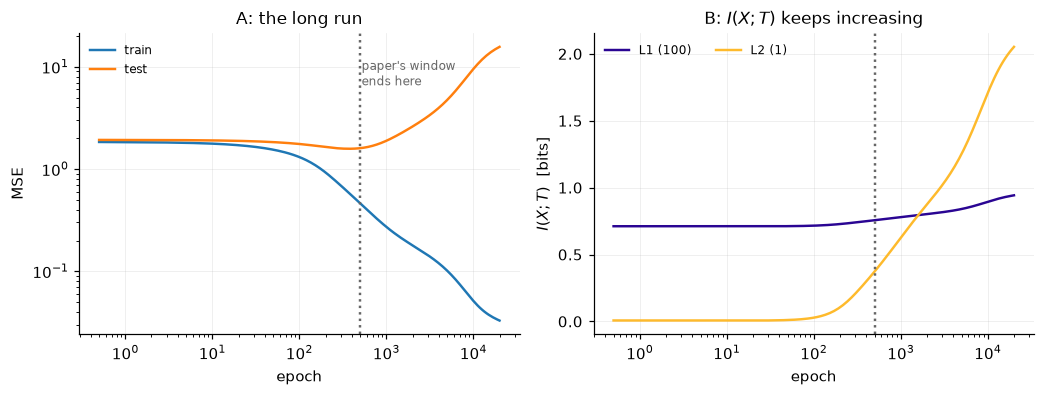

test MSE @ epoch 500   : 1.60
test MSE @ epoch 20000 : 15.66
max compression over the whole 20000 epochs: +0.0000 bits


In [9]:
cfg_long = LinearConfig(hidden=(100,), n_train=100, batch_size=None, lr=0.02,
                        n_epochs=20_000, n_checkpoints=120, seed=0)
res_long = cached(cfg_long.tag, lambda: run_linear(cfg_long))
Ll = res_long.log

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.7))
ax = axes[0]
ax.plot(np.maximum(Ll.epochs, 0.5), Ll.train_loss, label="train", color="#1f77b4")
ax.plot(np.maximum(Ll.epochs, 0.5), Ll.test_loss, label="test", color="#ff7f0e")
ax.axvline(500, ls=":", color="0.4")
ax.text(520, ax.get_ylim()[1] * 0.4, "paper's window\nends here", fontsize=8, color="0.4")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE"); ax.set_title("A: the long run")
ax.legend()

plotting.layer_curves(Ll.epochs, res_long.I_XT, ax=axes[1], layer_names=Ll.layer_names,
                      ylabel=r"$I(X;T)$  [bits]", title="B: $I(X;T)$ keeps increasing")
axes[1].axvline(500, ls=":", color="0.4")
fig.tight_layout()
plotting.save(fig, "fig03_long_run", FIGDIR)
plt.show()

print(f"test MSE @ epoch 500   : {np.interp(500, Ll.epochs, Ll.test_loss):.2f}")
print(f"test MSE @ epoch 20000 : {Ll.test_loss[-1]:.2f}")
print(f"max compression over the whole 20000 epochs: "
      f"{max(res_long.I_XT.max(0) - res_long.I_XT[-1]):+.4f} bits")

## Takeaways

1. In deep linear networks the information plane can be computed **exactly**. No
   compression appears — in any layer, at any depth, under SGD or BGD, over 500 epochs or
   20 000.
2. Since the computation is exact, this is **not** an estimator artefact. The mechanisms
   one might have hoped for — neurons becoming correlated, irrelevant directions being
   projected out — do not produce compression in this setting.
3. **The dissociation.** A network that generalises well (fig. 3) and one that overfits by
   a factor of ~14 (fig. 4) have indistinguishable information-plane trajectories. Whatever
   explains the difference in generalisation, it is not visible in $I(X;T)$.
4. Equation (C.5): networks computing *identical functions* can be assigned arbitrarily
   different $I(T;X)$ by rescaling their weights. A quantity that varies while the function
   is fixed cannot be measuring a property of the function.

Next: [`04_sgd_vs_bgd.ipynb`](04_sgd_vs_bgd.ipynb) tests the third claim — that SGD's
diffusion causes compression.